# NEGF Time Evolution GUI

This notebook implements an interactive GUI for handling HDF5 files, visualizing parameters, setting up spatial masks, selecting quasiparticles, configuring laser and VCAP parameters, and running time evolution simulations.

In [1]:
import atomic_units as au
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import matplotlib.pyplot as plt
from quantum_toolkit import potentials as pots
import quantum_toolkit as quat
import scipy.sparse as sparse
import numpy as np
import json
import deepdish as dd
import os
import threading
import time

display(HTML("""
<style>
.output_scroll {overflow: visible !important; max-height: none !important;}
.potparam-row > .widget-label { min-width: 90px; }
.potparam-row > .widget-label, .potparam-row > .widget-inline-hbox { margin-right: 8px; }
</style>
"""))

In [2]:
uxgrid = None
utgrid = None
unit_sys = None
modelpot = None
dispersion = None
laserpot = None

# --- MASK deklarációk ---
mask = None  # mindig aktuális maszkoló logikai tömb (bool)
uxgrid_masked = None  # mindig aktuális maszkolt rács (uxgrid[mask])

# Default values
default_spot_size_nm = 80
default_field_strength_gvm = 1.0
default_central_wavelength_nm = 800
default_num_of_cycles = 5
default_beta = 0.2

quasiparticles_pk = []
quasiparticles_mk = []

# Átnevezve: kiválasztottak listái (always sync with states_compute_select)
quasiparticles_to_compute_pk = []
quasiparticles_to_compute_mk = []

# --- Measurement points globális lista (always up-to-date) ---
measurement_points_nm = []
measurement_points_au = []
measurement_points_indices = []

## 1. File Operations

Specify the path and name of the HDF5 file, then load the parameters.

In [3]:
directory_widget = widgets.Text(
    value=os.getcwd(),
    description="Directory:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Input file name mező (átnevezve)
input_filename_widget = widgets.Text(
    value="scatter_20250609_1.h5",
    description="Input file name:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Output file name mező (új)
output_filename_widget = widgets.Text(
    value="output_20250609_1.h5",
    description="Output file name:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# A directory_widget változatlan marad

def get_hdf5_path():
    return os.path.join(directory_widget.value, input_filename_widget.value)

load_hdf5_button = widgets.Button(description="Load", button_style='warning')

files_status_html = widgets.HTML(value="")

def build_modelpot_from_loaded(uxgrid, wallwidth, wallheight, wallrise, wellwidth, welldepth, wellfall, num_cells, cell_spacing, unit_sys):
    class LoadedPotential(pots.Potential):
        def __init__(self, grid, values):
            super().__init__(grid)
            self.values = values
        def __call__(self, t=0):
            return self.values
        def value_at(self, x, t=0):
            return np.interp(x, self.grid, self.values)

    wallwidth = wallwidth * unit_sys.convert_length_from('nm')
    wallheight = wallheight * unit_sys.convert_energy_from('eV')
    wallrise = wallrise
    wellwidth = wellwidth * unit_sys.convert_length_from('nm')
    welldepth = welldepth * unit_sys.convert_energy_from('eV')
    wellfall = wellfall
    num_cells = num_cells
    cell_spacing = cell_spacing * unit_sys.convert_length_from('nm')

    cell_length_nm = 2*wallwidth/unit_sys.convert_length_from('nm') + wellwidth/unit_sys.convert_length_from('nm') + cell_spacing/unit_sys.convert_length_from('nm')
    cell_length_unit = cell_length_nm * unit_sys.convert_length_from('nm')

    pot = np.zeros_like(uxgrid)
    for i in range(num_cells):
        offset = (i - (num_cells-1)/2) * cell_length_unit
        cell_pot = pots.SmoothStackPotential(
            uxgrid - offset,
            wallwidth=wallwidth,
            wallheight=wallheight,
            welldepth=welldepth,
            wellwidth=wellwidth,
            wallrise=wallrise,
            wellfall=wellfall
        )(0)
        pot += cell_pot
    return LoadedPotential(uxgrid, pot)

def load_from_hdf5(btn):
    global uxgrid, uxgrid_dx, unit_sys, modelpot
    global quasiparticles_pk, quasiparticles_mk 
    path = get_hdf5_path()
    try:
        if os.path.exists(path):
            data = dd.io.load(path)
            hb = data['unit_sys']['hb']
            m0 = data['unit_sys']['m0']
            k0 = data['unit_sys']['k0']
            e0 = data['unit_sys']['e0']
            unit_sys = au.AtomicUnitSystem(xh=hb, xe=e0, xm=m0, xk=k0)

            # uxgrid visszaállítása közvetlenül a fájlból
            uxgrid = data['grid']['uxgrid']
            uxgrid_num = data['grid']['num']
            uxgrid_width_nm = data['grid']['width_nm']
            uxgrid_width_au = data['grid']['width_au']
            uxgrid_dx = uxgrid[1] - uxgrid[0]

            # Potenciál paraméterek visszaállítása
            wallwidth = data['potential']['wallwidth']
            wallheight = data['potential']['wallheight']
            wallrise = data['potential']['wallrise']
            wellwidth = data['potential']['wellwidth']
            welldepth = data['potential']['welldepth']
            wellfall = data['potential']['wellfall']
            num_cells = data['potential']['num_cells']
            cell_spacing = data['potential'].get('cell_spacing', 0.0)
            # modelpot_values = data['potential']['values']
            modelpot = build_modelpot_from_loaded(
                uxgrid, wallwidth, wallheight, wallrise, wellwidth, welldepth, wellfall, num_cells, cell_spacing, unit_sys
            )

            # Dispersion tab paraméterek visszatöltése
            disp_energy_min_ev = data['dispersion']['energy_min_ev']
            disp_energy_min_au = data['dispersion']['energy_min_au']
            disp_energy_max_ev = data['dispersion']['energy_max_ev']
            disp_energy_max_au = data['dispersion']['energy_max_au']
            disp_number_of_points = data['dispersion']['number_of_points']
            
            dispersion = quat.CosineDispersion(
                uxgrid_dx,
                hbar=hb,
                mass=m0
            )

            # Quasi-particle adatok visszatöltése (mindig, akár üres is lehet)
            quasiparticles = data.get('quasiparticles', {})
            # --- fix: globális lista helyett clear() + extend() ---
            quasiparticles_pk.clear()
            quasiparticles_pk.extend(list(quasiparticles.get('pk', [])))
            quasiparticles_mk.clear()
            quasiparticles_mk.extend(list(quasiparticles.get('mk', [])))

            files_status_html.value = f"<span style='color:green'>Loaded successfully: {path}</span>"
        else:
            files_status_html.value = f"<span style='color:red'>File not found: {path}</span>"
    except Exception as e:
        files_status_html.value = f"<span style='color:red'>Error during loading: {str(e)}</span>"

def save_to_hdf5(btn):
    print("Saving to HDF5...")

load_hdf5_button.on_click(load_from_hdf5)

# Load gomb a mező mellé
input_row = widgets.HBox([
    input_filename_widget,
    load_hdf5_button
])

# Új files_tab elrendezés
files_tab = widgets.VBox([
    directory_widget,
    input_row,
    files_status_html,
    output_filename_widget
])

## 2. Grid Parameters

Set temporal and spatial grid parameters and visualize them automatically.

In [4]:
# New Grid tab: set time (utgrid) and space (uxgrid) parameters

import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Time (utgrid) parameters ---
utgrid_num_widget = widgets.IntText(
    value=500,
    description="Number of time points:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
utgrid_tmin_widget = widgets.FloatText(
    value=0.0,
    description="Start time [a.u.]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
utgrid_tmax_widget = widgets.FloatText(
    value=100.0,
    description="End time [a.u.]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

utgrid_dx_label = widgets.Label(value="dt: --- [a.u.]", layout=widgets.Layout(width='200px'))

def update_utgrid(change=None):
    num = max(2, utgrid_num_widget.value)
    tmin = utgrid_tmin_widget.value
    tmax = utgrid_tmax_widget.value
    if tmax <= tmin:
        tmax = tmin + 1.0
        utgrid_tmax_widget.value = tmax
    dt = (tmax - tmin) / (num - 1)
    utgrid_dx_label.value = f"dt: {dt:.6g} [a.u.]"
    
    global utgrid
    utgrid = np.linspace(tmin, tmax, num)

for w in [utgrid_num_widget, utgrid_tmin_widget, utgrid_tmax_widget]:
    w.observe(update_utgrid, names='value')
update_utgrid()

# --- Space (uxgrid) parameters (display only) ---
uxgrid_num_label = widgets.Label(f"Number of points: {len(uxgrid) if uxgrid is not None else '-'}", layout=widgets.Layout(width='200px'))
uxgrid_min_label = widgets.Label(f"x_min: {uxgrid[0]:.3g}" if uxgrid is not None else "x_min: ---", layout=widgets.Layout(width='200px'))
uxgrid_max_label = widgets.Label(f"x_max: {uxgrid[-1]:.3g}" if uxgrid is not None else "x_max: ---", layout=widgets.Layout(width='200px'))
uxgrid_dx_label = widgets.Label(f"dx: {uxgrid_dx:.3g}" if 'uxgrid_dx' in globals() and uxgrid_dx is not None else "dx: ---", layout=widgets.Layout(width='200px'))

def update_uxgrid_labels():
    if uxgrid is not None:
        uxgrid_num_label.value = f"Number of points: {len(uxgrid)}"
        uxgrid_min_label.value = f"x_min: {uxgrid[0]:.3g}"
        uxgrid_max_label.value = f"x_max: {uxgrid[-1]:.3g}"
        uxgrid_dx_label.value = f"dx: {uxgrid_dx:.3g}"
    else:
        uxgrid_num_label.value = "Number of points: ---"
        uxgrid_min_label.value = "x_min: ---"
        uxgrid_max_label.value = "x_max: ---"
        uxgrid_dx_label.value = "dx: ---"

update_uxgrid_labels()

# --- ÚJ: Mask (spatial mask) paraméterek és vizualizáció, ritkított griddel és kiemelt pontokkal ---
mask_enable_checkbox = widgets.Checkbox(value=False, description="Enable mask")
measurement_points_text = widgets.Text(
    value="-121,119",
    description="Measurement points [nm]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)
points_around_each_widget = widgets.IntText(
    value=5,
    description="Points around each:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
mask_points_widget = widgets.IntText(
    value=1024,
    description="Number of points (reduced):",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)
mask_plot_output = widgets.Output()

def update_measurement_points():
    global measurement_points_nm, measurement_points_au, measurement_points_indices
    # Parse measurement points from text field
    try:
        measurement_points_nm = []
        for part in measurement_points_text.value.split(','):
            if not part.strip():
                continue
            measurement_points_nm.append(float(part.strip()))
    except Exception:
        measurement_points_nm = []
    # Convert to atomic units if possible
    if unit_sys is not None:
        measurement_points_au = [mp * unit_sys.convert_length_from('nm') for mp in measurement_points_nm]
    else:
        measurement_points_au = []
    # ÚJ: indexek meghatározása uxgrid-ben
    measurement_points_indices = []
    if uxgrid is not None and unit_sys is not None and measurement_points_nm:
        uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
        for mp_nm in measurement_points_nm:
            idx = np.abs(uxgrid_nm - mp_nm).argmin()
            measurement_points_indices.append(idx)
    else:
        measurement_points_indices = []

measurement_points_text.observe(lambda change: update_measurement_points(), names='value')
# Frissítsük induláskor is
update_measurement_points()

def parse_measurement_points(points_str):
    """E.g. '-121,119' -> [-121.0, 119.0]"""
    try:
        points = []
        for part in points_str.split(','):
            if not part.strip():
                continue
            points.append(float(part.strip()))
        return points
    except Exception:
        return []

def update_mask_and_masked_uxgrid():
    global mask, uxgrid_masked
    # --- measurement_points_nm, measurement_points_au always up-to-date ---
    if uxgrid is None:
        mask = None
        uxgrid_masked = None
        return
    uxgrid_num = len(uxgrid)
    desired_points = mask_points_widget.value
    step_size = max(1, uxgrid_num // max(1, desired_points))
    mask_arr = np.zeros(uxgrid_num, dtype=bool)
    mask_arr[::step_size] = True
    # Measurement points logika
    points_around = max(0, points_around_each_widget.value)
    if unit_sys is not None and measurement_points_nm:
        uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
        for mp_nm in measurement_points_nm:
            idx = np.abs(uxgrid_nm - mp_nm).argmin()
            left = max(0, idx - points_around)
            right = min(uxgrid_num, idx + points_around + 1)
            mask_arr[left:right] = True
    if mask_enable_checkbox.value:
        mask = mask_arr
    else:
        mask = np.ones(uxgrid_num, dtype=bool)
    uxgrid_masked = uxgrid[mask]

def update_mask_plot(*args):
    update_measurement_points()
    update_mask_and_masked_uxgrid()
    if uxgrid is None or unit_sys is None:
        with mask_plot_output:
            mask_plot_output.clear_output()
            print("A rács vagy a mértékegység nincs inicializálva.")
        return
    uxgrid_num = len(uxgrid)
    uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
    with mask_plot_output:
        mask_plot_output.clear_output()
        import matplotlib.pyplot as plt
        plt.figure(figsize=(7,2.5))
        plt.plot(uxgrid_nm, np.zeros_like(uxgrid_nm), 'o', markersize=2, label='Original uxgrid')
        plt.plot(uxgrid_nm[mask], np.zeros_like(uxgrid_nm[mask]), 'o', markersize=4, label='Active mask')
        # Measurement points: vertical lines
        for i, mp_nm in enumerate(measurement_points_nm):
            plt.axvline(mp_nm, color='orange', alpha=0.7, linestyle='--', label='Measurement point' if i == 0 else None)
        plt.xlabel('x [nm]')
        plt.ylabel('Value')
        plt.title('Mask visualization')
        plt.legend()
        plt.show()
        print(f"Number of masked points: {np.sum(mask)} / {uxgrid_num}")

mask_enable_checkbox.observe(update_mask_plot, names='value')
measurement_points_text.observe(update_mask_plot, names='value')
points_around_each_widget.observe(update_mask_plot, names='value')
mask_points_widget.observe(update_mask_plot, names='value')

update_mask_plot()

# --- Tab layout ---
grid_tab = widgets.VBox([
    widgets.Label("Time (utgrid) parameters:"),
    widgets.VBox([utgrid_num_widget, utgrid_tmin_widget, utgrid_tmax_widget, utgrid_dx_label]),
    widgets.Label("Space (uxgrid) parameters:"),
    widgets.VBox([uxgrid_num_label, uxgrid_min_label, uxgrid_max_label, uxgrid_dx_label]),
    widgets.Label("Spatial mask parameters:"),
    widgets.VBox([
        mask_enable_checkbox,
        mask_points_widget, 
        measurement_points_text,
        points_around_each_widget,
        mask_plot_output
    ])
])

## 3. States Tab – Állapotlista és TR plot

Az összes betöltött állapot listája, valamint a Transmission/Reflection plot, ahol a kiválasztott állapot piros színnel látható.

In [5]:
# States tab: állapotlista + TR plot, kiválasztott állapot kiemelése

from ipywidgets import Dropdown, VBox, HBox, Output, Label, ToggleButtons, SelectMultiple

# Lista widget: minden betöltött állapot (index, energia, k)
def make_states_options():
    options = []
    for i, qp in enumerate(quasiparticles_pk):
        e_ev = qp.get('energy', 0) * unit_sys.energy_unit.to('eV').magnitude
        k_nm = qp.get('wavenumber', 0) * unit_sys.length_unit.to('nm').magnitude
        label = f"{i}: E={e_ev:.3f} eV, k={k_nm:.3f} 1/nm"
        options.append((label, i))
    return options

# Új: kiválasztandó quasiparticle lista (többes választás)
states_compute_select = SelectMultiple(
    options=make_states_options(),
    value=tuple(range(len(quasiparticles_pk))) if quasiparticles_pk else (),
    description='',
    layout=widgets.Layout(width='350px', height='120px')
)

states_select = Dropdown(
    options=make_states_options(),
    value=0 if quasiparticles_pk else None,
    description='',  # Use empty string instead of None to avoid TraitError
    layout=widgets.Layout(width='350px')
)

# Új: ToggleButtons a plot x tengelyéhez
states_tr_plot_mode = ToggleButtons(
    options=[('k', 'k'), ('energy', 'energy')],
    value='k',
    description='X axis:',
    style={'description_width': 'initial'}
)

states_tr_plot_output = Output(layout=widgets.Layout(width='400px', height='220px'))

# Új: hullámfüggvény plot output
states_wavefunc_plot_output = Output(layout=widgets.Layout(width='400px', height='400px'))

def update_selected_quasiparticles(*args):
    # Frissíti a selected_quasiparticles_pk/mk listákat a kiválasztott indexek alapján
    global selected_quasiparticles_pk, selected_quasiparticles_mk
    global quasiparticles_to_compute_pk, quasiparticles_to_compute_mk
    indices = list(states_compute_select.value)
    selected_quasiparticles_pk = [quasiparticles_pk[i] for i in indices] if quasiparticles_pk else []
    selected_quasiparticles_mk = [quasiparticles_mk[i] for i in indices] if quasiparticles_mk else []
    # Szinkronizáljuk a "to_compute" listákat is
    quasiparticles_to_compute_pk.clear()
    quasiparticles_to_compute_pk.extend(selected_quasiparticles_pk)
    quasiparticles_to_compute_mk.clear()
    quasiparticles_to_compute_mk.extend(selected_quasiparticles_mk)

def update_states_options(*args):
    # Frissíti a listát, ha változik a quasiparticles_pk
    options = make_states_options()
    states_select.options = options
    if len(states_select.options) > 0:
        states_select.value = 0
    states_compute_select.options = options
    if len(states_compute_select.options) > 0 and not states_compute_select.value:
        states_compute_select.value = tuple(range(len(options)))
    update_selected_quasiparticles()  # Új: szinkronizálás
    update_states_tr_plot()
    update_states_wavefunc_plot()

def update_states_tr_plot(*args):
    with states_tr_plot_output:
        states_tr_plot_output.clear_output()
        if not quasiparticles_pk or len(quasiparticles_pk) == 0:
            print("Nincs elérhető állapot.")
            return
        idx = states_select.value if states_select.value is not None else 0
        qp_pk = quasiparticles_pk
        # x tengely: energy vagy k
        if states_tr_plot_mode.value == 'k':
            x_vals = [qp.get('wavenumber', 0) * unit_sys.length_unit.to('nm').magnitude if unit_sys else qp.get('wavenumber', 0) for qp in qp_pk]
            x_label = "k [1/nm]"
        else:
            x_vals = [qp.get('energy', 0) * unit_sys.energy_unit.to('eV').magnitude if unit_sys else qp.get('energy', 0) for qp in qp_pk]
            x_label = "Energy [eV]"
        t_vals = [qp.get('transmission', 0) for qp in qp_pk]
        r_vals = [qp.get('reflection', 0) for qp in qp_pk]
        plt.figure(figsize=(6, 2.5))
        plt.plot(x_vals, t_vals, '-o', label='Transmission', color='C0')
        plt.plot(x_vals, r_vals, '-o', label='Reflection', color='C1')
        # Kiemelt pont piros színnel
        if idx is not None and idx < len(x_vals):
            plt.scatter([x_vals[idx]], [t_vals[idx]], color='red', s=80, zorder=5)
            plt.scatter([x_vals[idx]], [r_vals[idx]], color='red', s=80, zorder=5)
        plt.xlabel(x_label)
        plt.ylabel("Coefficient")
        plt.title("Transmission/Reflection")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

def update_states_wavefunc_plot(*args):
    with states_wavefunc_plot_output:
        states_wavefunc_plot_output.clear_output()
        if not quasiparticles_pk or len(quasiparticles_pk) == 0:
            print("Nincs elérhető állapot.")
            return
        idx = states_select.value

        # pk állapot
        qp_pk = quasiparticles_pk[idx]['state']
        qp_mk = quasiparticles_mk[idx]['state']
        # pk plot
        #plt.figure(figsize=(8,2.5))
        plt.plot(qp_pk['grid'], np.real(qp_pk['value']), label='Re (+k)')
        plt.plot(qp_pk['grid'], np.imag(qp_pk['value']), label='Im (+k)')
        plt.plot(qp_pk['grid'], np.abs(qp_pk['value']), label='Abs (+k)')
        plt.xlim(-20, 20)
        plt.xlabel("x")
        plt.ylabel("Amplitude")
        plt.title("Wavefunction (+k)")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

        #plt.figure(figsize=(8,2.5))
        plt.plot(qp_mk['grid'], np.real(qp_mk['value']), label='Re (-k)')
        plt.plot(qp_mk['grid'], np.imag(qp_mk['value']), label='Im (-k)')
        plt.plot(qp_mk['grid'], np.abs(qp_mk['value']), label='Abs (-k)')
        plt.xlim(-20, 20)
        plt.xlabel("x")
        plt.ylabel("Amplitude")
        plt.title("Wavefunction (-k)")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

states_select.observe(update_states_tr_plot, names='value')
states_select.observe(update_states_wavefunc_plot, names='value')
states_tr_plot_mode.observe(update_states_tr_plot, names='value')

# Új: a states_compute_select widget változására is frissítjük a kiválasztott listákat
states_compute_select.observe(update_selected_quasiparticles, names='value')

states_tab = VBox([
    widgets.Label("Quasiparticles to compute"),
    states_compute_select,
    widgets.Label("Quasiparticle to plot"),
    states_select,
    states_tr_plot_mode,
    states_tr_plot_output,
    states_wavefunc_plot_output
])

## VCAP

In [6]:
# VCAP tab: parameters and visualization
import ipywidgets as widgets
from IPython.display import display, clear_output

v_cap = None  # Placeholder for VCAP data

# VCAP parameter widgets
vcap_x0_widget = widgets.FloatText(
    value=100.0,
    description="param_x0:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
vcap_lambda0_widget = widgets.FloatText(
    value=0.1,
    description="param_lambda0:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)
vcap_plot_output = widgets.Output()

def update_vcap_plots(*args):
    global uxgrid, v_cap
    with vcap_plot_output:
        clear_output(wait=True)
        
        # parameters
        param_x0 = vcap_x0_widget.value
        param_lambda0 = vcap_lambda0_widget.value
        v_cap = quat.vcap_generator(uxgrid, param_x0=param_x0, param_lambda0=param_lambda0)

        uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
        x_label = "x [nm]"

        # 1. plot: abs and angle
        plt.figure(figsize=(6,2.5))
        plt.plot(uxgrid_nm, np.abs(v_cap[0]), label="|Vcap[0]|")
        plt.plot(uxgrid_nm, np.angle(v_cap[0]), label="Angle{Vcap[0]}")
        plt.legend()
        plt.grid()
        plt.title("VCAP[0]: abs and angle")
        plt.xlabel(x_label)
        plt.tight_layout()
        plt.show()
        # 2. plot: Re/Im v_cap[1]
        plt.figure(figsize=(6,2.5))
        plt.plot(uxgrid_nm, np.real(v_cap[1]), label="Re{Vcap[1]}")
        plt.plot(uxgrid_nm, np.imag(v_cap[1]), label="Im{Vcap[1]}")
        plt.legend()
        plt.grid()
        plt.title("VCAP[1]: Re and Im")
        plt.xlabel(x_label)
        plt.tight_layout()
        plt.show()
        # 3. plot: Re/Im v_cap[2]
        plt.figure(figsize=(6,2.5))
        plt.plot(uxgrid_nm, np.real(v_cap[2]), label="Re{Vcap[2]}")
        plt.plot(uxgrid_nm, np.imag(v_cap[2]), label="Im{Vcap[2]}")
        plt.legend()
        plt.grid()
        plt.title("VCAP[2]: Re and Im")
        plt.xlabel(x_label)
        plt.tight_layout()
        plt.show()

# Auto update on parameter change
vcap_x0_widget.observe(update_vcap_plots, names='value')
vcap_lambda0_widget.observe(update_vcap_plots, names='value')

update_vcap_plots()

vcap_tab = widgets.VBox([
    widgets.Label("VCAP parameters and visualization:"),
    vcap_x0_widget, vcap_lambda0_widget,
    vcap_plot_output
])

## 5. Laser Field Configuration

Set external laser field parameters and visualize them.

In [ ]:
# Laser field parameter widgets
laser_spot_size_widget = widgets.FloatText(
    value=default_spot_size_nm,
    description="Spot size [nm]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
laser_field_strength_widget = widgets.FloatText(
    value=default_field_strength_gvm,
    description="Field strength [GV/m]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
laser_wavelength_widget = widgets.FloatText(
    value=default_central_wavelength_nm,
    description="Wavelength [nm]:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
laser_cycles_widget = widgets.IntText(
    value=default_num_of_cycles,
    description="Number of cycles:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)
laser_beta_widget = widgets.FloatText(
    value=default_beta,
    description="Beta:",
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='250px')
)

laser_plot_output = widgets.Output()

def update_laser_plot(*args):
    global uxgrid, unit_sys, laserpot
    if uxgrid is None or unit_sys is None:
        laser_plot_output.clear_output()
        with laser_plot_output:
            print("Error: uxgrid or unit_sys is not initialized.")
        return
    laser_plot_output.clear_output()

    with laser_plot_output:

        # Parameters
        spot_size_nm = laser_spot_size_widget.value
        field_strength_gvm = laser_field_strength_widget.value
        central_wavelength_nm = laser_wavelength_widget.value
        num_of_cycles = laser_cycles_widget.value
        beta = laser_beta_widget.value

        # Laser parameter conversion

        central_wavelength = central_wavelength_nm * unit_sys.convert_length_from("nm")
        s_min = -0.5 * spot_size_nm * unit_sys.convert_length_from("nm")
        s_max = 0.5 * spot_size_nm * unit_sys.convert_length_from("nm")
        magnitude = field_strength_gvm * unit_sys.convert_electric_field_from("GV/m")
        omega = 2 * np.pi * unit_sys.speed_of_light / central_wavelength_nm
        t_min = 0
        t_max = num_of_cycles * 2 * np.pi / omega
        utgrid_dt = 0.05
        utgrid = np.arange(t_min, t_max, utgrid_dt)
        uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
        tvals_fs = utgrid * unit_sys.time_unit.to('fs').magnitude
        field_unit_gvm = unit_sys.electric_field_unit.to('GV/m').magnitude


        # Laser field object

        laserpot = pots.SmoothLaserPotential(
            uxgrid,
            spatial_min=s_min, spatial_max=s_max,
            temporal_max=t_max, temporal_min=t_min,
            noc=num_of_cycles,
            amplitude=magnitude,
            beta=beta
        )

        # Plot: spatial profile at a given time
        plt.figure(figsize=(6,2.5))
        plt.plot(
            uxgrid_nm,
            laserpot(laserpot.temporal_width/2) * field_unit_gvm,
            label="Laser (spatial profile)"
        )
        plt.xlabel("x [nm]")
        plt.ylabel("Field [GV/m]")
        plt.title("Laser field spatial profile (mid time)")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Plot: temporal profile at x=0
        plt.figure(figsize=(6,2.5))
        x0_idx = np.abs(uxgrid).argmin()
        yvals = [laserpot.value_at(uxgrid[x0_idx], t) * field_unit_gvm for t in utgrid]
        plt.plot(tvals_fs, yvals, label="Laser (temporal profile, x=0)")
        plt.xlabel("time [fs]")
        plt.ylabel("Field [GV/m]")
        plt.title("Laser field temporal profile (x=0)")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

for w in [laser_spot_size_widget, laser_field_strength_widget, laser_wavelength_widget, laser_cycles_widget, laser_beta_widget]:
    w.observe(update_laser_plot, names='value')

update_laser_plot()

laser_tab = widgets.VBox([
    widgets.Label("External laser field parameters:"),
    laser_spot_size_widget, laser_field_strength_widget,
    laser_wavelength_widget, laser_cycles_widget, laser_beta_widget,
    laser_plot_output
])

In [8]:
# TEMP FILE alapú beállítás-mentés/betöltés (scatter_gui mintájára)
import json

SETTINGS_FILE = "/tmp/time_evolution_gui2_settings.json"

def save_settings_to_file():
    try:
        settings = {
            "files": {
                "directory": directory_widget.value,
                "input_filename": input_filename_widget.value,
                "output_filename": output_filename_widget.value
            },
            "grid": {
                "utgrid_num": utgrid_num_widget.value,
                "utgrid_tmin": utgrid_tmin_widget.value,
                "utgrid_tmax": utgrid_tmax_widget.value
            },
            "laser": {
                "spot_size_nm": laser_spot_size_widget.value,
                "field_strength_gvm": laser_field_strength_widget.value,
                "wavelength_nm": laser_wavelength_widget.value,
                "num_of_cycles": laser_cycles_widget.value,
                "beta": laser_beta_widget.value
            },
            "vcap": {
                "x0": vcap_x0_widget.value,
                "lambda0": vcap_lambda0_widget.value
            },
            "states": {
                "compute_indices": list(states_compute_select.value) if hasattr(states_compute_select, "value") else []
            }
        }
        with open(SETTINGS_FILE, "w") as f:
            json.dump(settings, f, indent=2)
    except Exception as e:
        pass  # Ignore errors

def load_settings_from_file():
    try:
        with open(SETTINGS_FILE, "r") as f:
            settings = json.load(f)
        files = settings.get("files", {})
        grid = settings.get("grid", {})
        laser = settings.get("laser", {})
        vcap = settings.get("vcap", {})
        states = settings.get("states", {})

        directory_widget.value = files.get("directory", directory_widget.value)
        input_filename_widget.value = files.get("input_filename", input_filename_widget.value)
        output_filename_widget.value = files.get("output_filename", output_filename_widget.value)

        utgrid_num_widget.value = grid.get("utgrid_num", utgrid_num_widget.value)
        utgrid_tmin_widget.value = grid.get("utgrid_tmin", utgrid_tmin_widget.value)
        utgrid_tmax_widget.value = grid.get("utgrid_tmax", utgrid_tmax_widget.value)

        laser_spot_size_widget.value = laser.get("spot_size_nm", laser_spot_size_widget.value)
        laser_field_strength_widget.value = laser.get("field_strength_gvm", laser_field_strength_widget.value)
        laser_wavelength_widget.value = laser.get("wavelength_nm", laser_wavelength_widget.value)
        laser_cycles_widget.value = laser.get("num_of_cycles", laser_cycles_widget.value)
        laser_beta_widget.value = laser.get("beta", laser_beta_widget.value)

        vcap_x0_widget.value = vcap.get("x0", vcap_x0_widget.value)
        vcap_lambda0_widget.value = vcap.get("lambda0", vcap_lambda0_widget.value)

        # States tab: compute indices visszaállítása, ha van elérhető opció
        compute_indices = states.get("compute_indices", [])
        if compute_indices and hasattr(states_compute_select, "options") and len(states_compute_select.options) > 0:
            # Csak azokat az indexeket állítsuk vissza, amelyek érvényesek
            valid_indices = [i for i in compute_indices if i < len(states_compute_select.options)]
            if valid_indices:
                states_compute_select.value = tuple(valid_indices)
    except Exception:
        pass  # Ignore if file does not exist or is invalid

# Betöltés induláskor
load_settings_from_file()

# Minden fő widget változására automatikus mentés
for w in [
    directory_widget, input_filename_widget, output_filename_widget,
    utgrid_num_widget, utgrid_tmin_widget, utgrid_tmax_widget,
    laser_spot_size_widget, laser_field_strength_widget, laser_wavelength_widget, laser_cycles_widget, laser_beta_widget,
    vcap_x0_widget, vcap_lambda0_widget,
    states_compute_select
]:
    w.observe(lambda change: save_settings_to_file(), names='value')

## 6. GUI Assembly

All tabs in one place, for easy access.

In [9]:
# Assemble tabs
tabs = widgets.Tab(children=[
    files_tab, grid_tab, states_tab, vcap_tab, laser_tab
])
tab_titles = [
    'Files', 'Grid', 'States', 'VCAP', 'Laser'
]
for i, title in enumerate(tab_titles):
    tabs.set_title(i, title)

def on_tab_change(change):
    if change['name'] == 'selected_index' and change['new'] == 1:
        update_uxgrid_labels()
    if change['name'] == 'selected_index' and change['new'] == 2:
        update_states_options()  # <-- EDDIG csak update_states_tr_plot() volt, most update_states_options()
    if change['name'] == 'selected_index' and change['new'] == 3:
        update_vcap_plots()
    if change['name'] == 'selected_index' and change['new'] == 4:
        update_laser_plot()

# Observe the selected index change to update the plot when switching to the Laser tab
tabs.observe(on_tab_change, names='selected_index')

display(tabs)

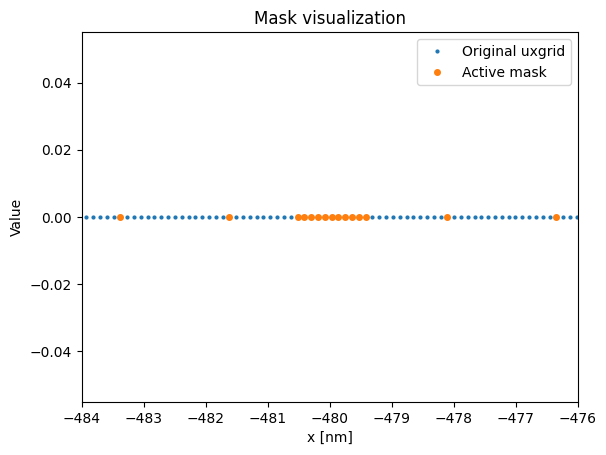

In [10]:
uxgrid_nm = uxgrid * unit_sys.length_unit.to('nm').magnitude
plt.plot(uxgrid_nm, np.zeros_like(uxgrid_nm), 'o', markersize=2, label='Original uxgrid')
plt.plot(uxgrid_nm[mask], np.zeros_like(uxgrid_nm[mask]), 'o', markersize=4, label='Active mask')
plt.xlim(-484, -476)
plt.xlabel('x [nm]')
plt.ylabel('Value')
plt.title('Mask visualization')
plt.legend()
plt.show()

In [11]:
print( type(uxgrid))
print(uxgrid_dx, type(uxgrid_dx))
print( type(utgrid))
print(unit_sys)
print(modelpot)
print(len(quasiparticles_pk), len(quasiparticles_mk))
print(len(quasiparticles_to_compute_pk), len(quasiparticles_to_compute_mk))

<class 'numpy.ndarray'>
0.04694239793428778 <class 'numpy.float64'>
<class 'numpy.ndarray'>
Value of atomic base units in this rescaled atomic units:
- modified planck constant hbar := 1.0
- elementary charge := 3.4
- electron mass := 8.8
- modified permittivity := 2.3

Derived units in this rescaled atomic unit system:
- length unit := 	2.340527796123471e-09 meter
- energy unit := 	1.9611842296327015e-20 joule
- time unit := 	5.37721954782219e-15 second
- frequency unit := 	185969717454628.9 hertz
- velocity unit := 	435267.2929397872 meter / second
- speed of light := 	688.7548475678182
- electric field unit := 	177816931.86098248 volt / meter
- electric potential unit := 	0.41618547164202274 volt

<__main__.build_modelpot_from_loaded.<locals>.LoadedPotential object at 0x76be05933460>
40 40
40 40


In [12]:
print(len(mask))
print(len(uxgrid_masked))

16384
1044


In [13]:
print(type(modelpot))
print(modelpot.grid)
print(type(laserpot))
print(laserpot.spatial_min, laserpot.spatial_max)

<class '__main__.build_modelpot_from_loaded.<locals>.LoadedPotential'>
[-384.52865268 -384.48171028 -384.43476788 ...  384.43476788  384.48171028
  384.52865268]
<class 'quantum_toolkit.potentials.SmoothLaserPotential'>
-170.9016234126786 170.9016234126786


In [14]:
print(type(v_cap))

<class 'numpy.ndarray'>


ein 0.9
0.9


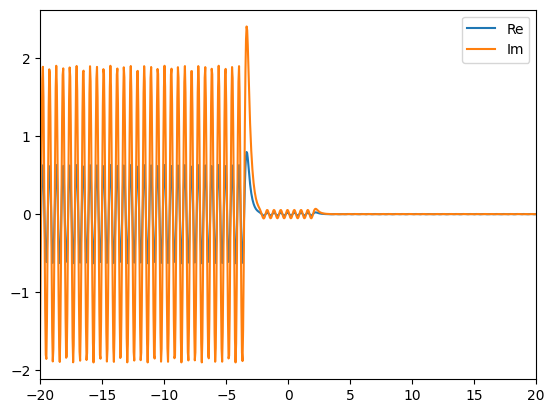

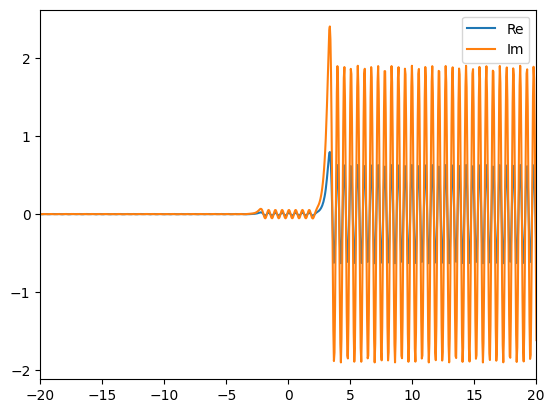

In [15]:
index=0
qp_pk = quasiparticles_pk[index]['state']
qp_mk = quasiparticles_mk[index]['state']
ein = quasiparticles_pk[index]['energy']
print("ein", ein* unit_sys.energy_unit.to('eV').magnitude)
print(ein* unit_sys.energy_unit.to('eV').magnitude)

plt.plot(qp_pk['grid'], np.real(qp_pk['value']), label='Re')
plt.plot(qp_pk['grid'], np.imag(qp_pk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

plt.plot(qp_mk['grid'], np.real(qp_mk['value']), label='Re')
plt.plot(qp_mk['grid'], np.imag(qp_mk['value']), label='Im')
plt.xlim(-20,20)
plt.legend()
plt.show()

In [16]:
utgrid_dt = (utgrid[1] - utgrid[0])
t_start = utgrid[0]
t_stop = utgrid[-1]

psipk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=ein/unit_sys.hb,\
                                            psi0_initial = qp_pk,\
                                            scalarpot = modelpot,\
                                            vectorpot=laserpot,\
                                            dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
                                            vcap=v_cap, mask=mask)

psimk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=ein/unit_sys.hb,\
                                            psi0_initial = qp_mk,\
                                            scalarpot = modelpot,\
                                            vectorpot=laserpot,\
                                            dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
                                            vcap=v_cap, mask=mask)
        
psipk_te.run()
psimk_te.run()

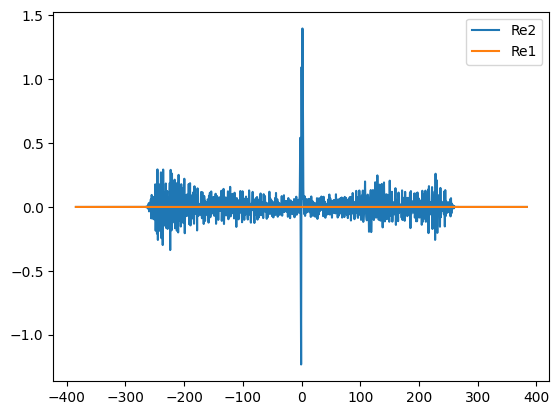

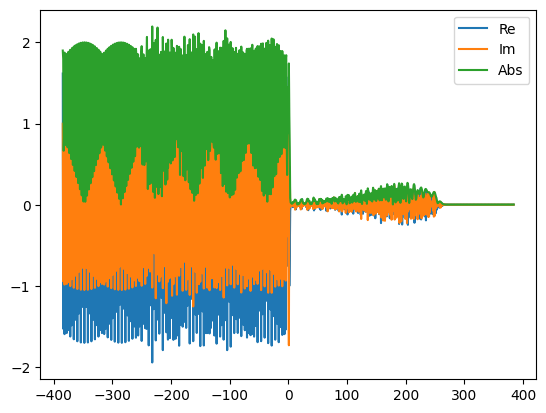

In [17]:
state_to_plot1 = psipk_te.psi1_time_evolution["value"][:,0]
state_to_plot2 = psimk_te.psi1_time_evolution["value"][:,-1]
plt.plot(uxgrid_masked, np.real(state_to_plot2),label="Re2")
plt.plot(uxgrid_masked, np.real(state_to_plot1),label="Re1")
plt.legend()
#plt.xlim(-10, 10)
plt.show()

#plot final state
state_to_plot = psipk_te.psi_time_evolution["value"][:,-1]
plt.plot(uxgrid_masked, np.real(state_to_plot),label="Re")
plt.plot(uxgrid_masked, np.imag(state_to_plot),label="Im")
plt.plot(uxgrid_masked, np.abs(state_to_plot),label="Abs")
plt.legend()
#plt.xlim(-10, 10)
plt.show()

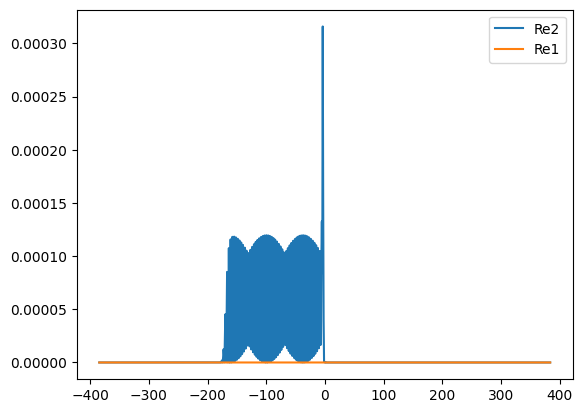

In [18]:
pd=quat.probability_density(psipk_te.psi1_time_evolution)
pd1=pd[:,0]
pd2=pd[:,100]
plt.plot(uxgrid_masked, np.real(pd2),label="Re2")
plt.plot(uxgrid_masked, np.real(pd1),label="Re1")
plt.legend()
#plt.xlim(-10, 10)
plt.show()

-132.38463664703164 132.38463664703164


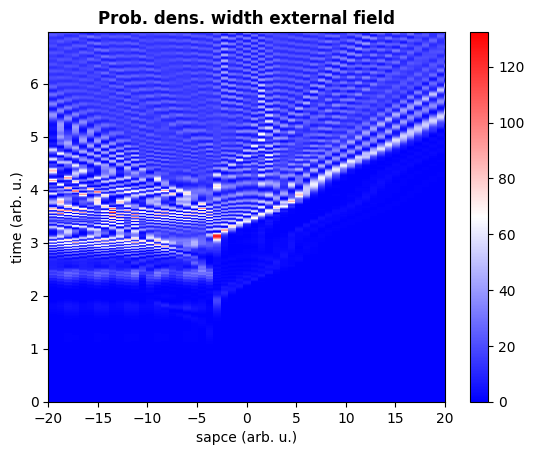

-144.91038417515006 144.91038417515006


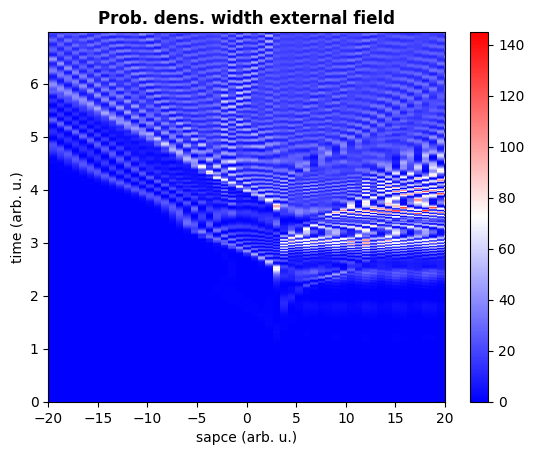

In [19]:
Xp,Yp = np.meshgrid(uxgrid_masked,utgrid[:-1])

Zp=np.transpose(quat.probability_density(psipk_te.psi1_time_evolution))

z_min, z_max = -np.abs(Zp).max(), np.abs(Zp).max()
print(z_min, z_max)
    
pcmp = plt.pcolormesh(Xp,Yp,Zp,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcmp)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim(2*laserpot.spatial_min, 2*laserpot.spatial_max)
plt.xlim(-20, 20)
plt.ylim(0,1.2*laserpot.temporal_width)
plt.show()

Xm,Ym = np.meshgrid(uxgrid_masked,utgrid[:-1])

Zm=np.transpose(quat.probability_density(psimk_te.psi1_time_evolution))

z_min, z_max = -np.abs(Zm).max(), np.abs(Zm).max()
print(z_min, z_max)
    
pcmm = plt.pcolormesh(Xm,Ym,Zm,cmap ='bwr') #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
plt.colorbar(pcmm)

plt.title('Prob. dens. width external field', fontweight ="bold")
plt.xlabel("sapce (arb. u.)")
plt.ylabel("time (arb. u.)")
#plt.xlim(2*laserpot.spatial_min, 2*laserpot.spatial_max)
plt.xlim(-20, 20)
plt.ylim(0,1.2*laserpot.temporal_width)
plt.show()

In [20]:
# --- Measurement points globális lista (always up-to-date) ---
print(measurement_points_nm)
print(measurement_points_au)

[-480.0, 480.0]
[-205.0819480952143, 205.0819480952143]


In [21]:
# choose masurement points on the right and the left side
meas_point_right=480*unit_sys.convert_length_from('nm')  # Right measurement point in atomic units
meas_point_left=-meas_point_right



left_index = np.abs(np.array(uxgrid_masked) - meas_point_left).argmin()#1300
right_index = np.abs(np.array(uxgrid_masked) - meas_point_right).argmin()#
x_left = uxgrid_masked[left_index]
x_right = uxgrid_masked[right_index]

print(left_index,x_left, x_left*unit_sys.length_unit.to('nm').magnitude)
print(right_index,x_right, x_right*unit_sys.length_unit.to('nm').magnitude)

244 -205.06786537583403 -479.96703900384546
800 205.06786537583406 479.9670390038455


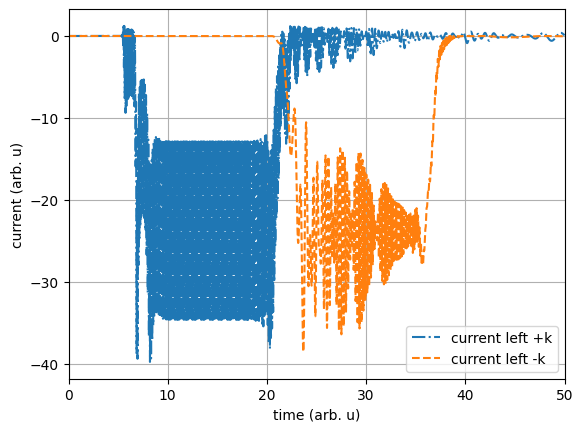

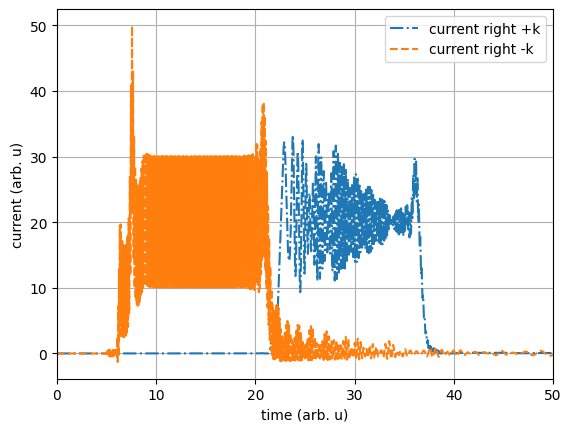

In [22]:
psi_left_pk = psipk_te.psi_time_evolution["value"][left_index,:]
dpsi_left_pk = (psipk_te.psi_time_evolution["value"][left_index+1,:]-psipk_te.psi_time_evolution["value"][left_index-1,:])/(2*uxgrid_dx)
j_left_pk = unit_sys.hb * np.imag(np.conj(psi_left_pk) * dpsi_left_pk) / unit_sys.me
psi_left_mk = psimk_te.psi_time_evolution["value"][left_index,:]
dpsi_left_mk = (psimk_te.psi_time_evolution["value"][left_index+1,:]-psimk_te.psi_time_evolution["value"][left_index-1,:])/(2*uxgrid_dx)
j_left_mk = unit_sys.hb * np.imag(np.conj(psi_left_mk) * dpsi_left_mk) / unit_sys.me
j_left = j_left_pk + j_left_mk

psi_right_pk = psipk_te.psi_time_evolution["value"][right_index,:]
dpsi_right_pk = (psipk_te.psi_time_evolution["value"][right_index+1,:]-psipk_te.psi_time_evolution["value"][right_index-1,:])/(2*uxgrid_dx)
j_right_pk = unit_sys.hb * np.imag(np.conj(psi_right_pk) * dpsi_right_pk) / unit_sys.me
psi_right_mk = psimk_te.psi_time_evolution["value"][right_index,:]
dpsi_right_mk = (psimk_te.psi_time_evolution["value"][right_index+1,:]-psimk_te.psi_time_evolution["value"][right_index-1,:])/(2*uxgrid_dx)
j_right_mk = unit_sys.hb * np.imag(np.conj(psi_right_mk) * dpsi_right_mk) / unit_sys.me
j_right = j_right_pk + j_right_mk

pc_pk_left = (unit_sys.hb / unit_sys.me) * quat.probability_current_at(psipk_te.psi_time_evolution, left_index)
pc_mk_left = (unit_sys.hb / unit_sys.me) * quat.probability_current_at(psimk_te.psi_time_evolution, left_index)
pc_pk_right = (unit_sys.hb / unit_sys.me) * quat.probability_current_at(psipk_te.psi_time_evolution, right_index)
pc_mk_right = (unit_sys.hb / unit_sys.me) * quat.probability_current_at(psimk_te.psi_time_evolution, right_index)

#plt.plot(utgrid[:-1], pc_pk_left + pc_mk_left, label="current left")
#plt.plot(utgrid[:-1], pc_pk_right + pc_mk_right, label="current right")
plt.plot(utgrid[:-1], j_left_pk,'-.',label="current left +k")
plt.plot(utgrid[:-1], j_left_mk,'--',label="current left -k")
#plt.plot(utgrid[:-1], j_right,'-.',label="current right")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u)")
plt.xlim(0,50)
plt.legend()
plt.grid()
plt.show()

plt.plot(utgrid[:-1], j_right_pk,'-.',label="current right +k")
plt.plot(utgrid[:-1], j_right_mk,'--',label="current right -k")
plt.xlabel("time (arb. u)")
plt.ylabel("current (arb. u)")
plt.xlim(0,50)
plt.legend()
plt.grid()
plt.show()


/tmp/ipykernel_2070256/3141835239.py:19: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):


1. run:
-electron energy:7.352491157192597.35249115719259
-electron wavenumber:11.515267746807963
Norm (t=0): 763.522, Norm (final): 776.302
Abs diff: 1.278e+01, Rel diff: 1.674e-02


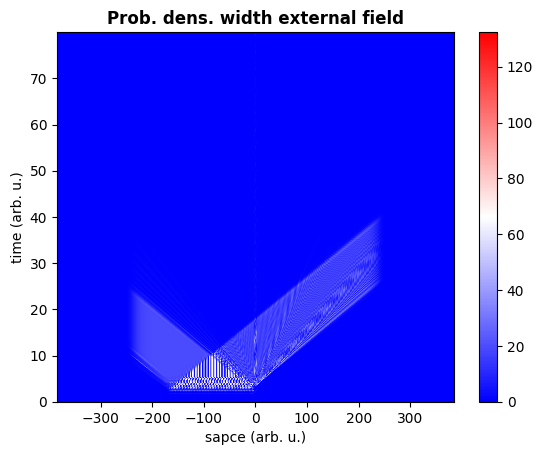

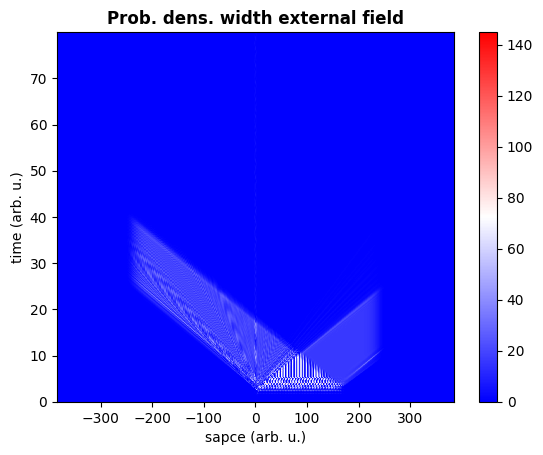

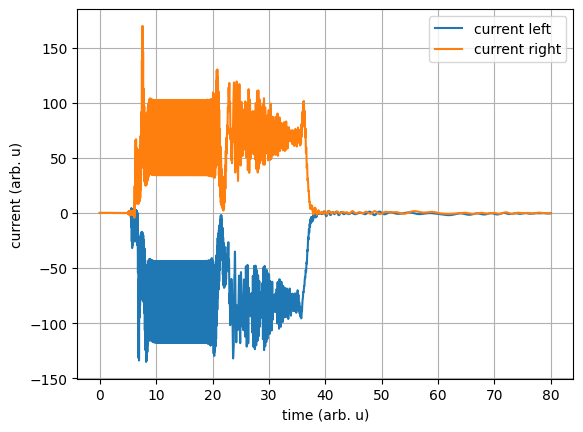

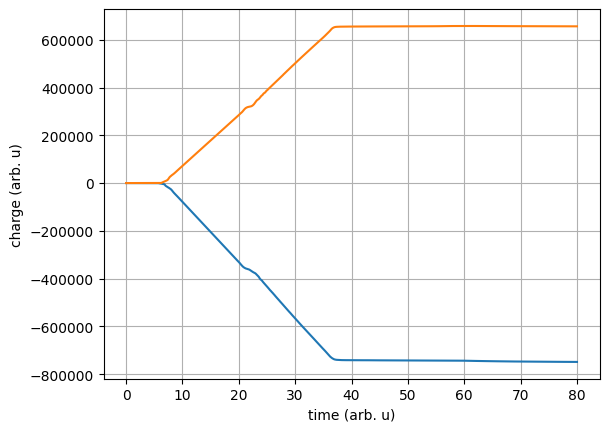

2. run:
-electron energy:7.4294239132259727.429423913225972
-electron wavenumber:11.576875507325523
Norm (t=0): 762.899, Norm (final): 775.123
Abs diff: 1.222e+01, Rel diff: 1.602e-02


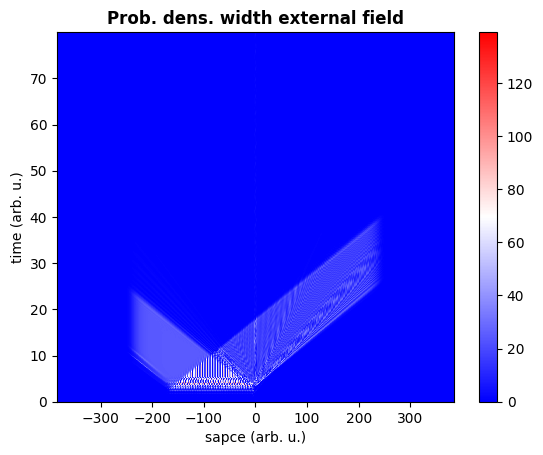

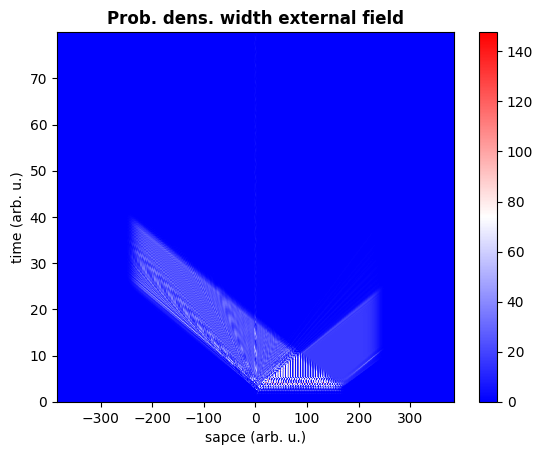

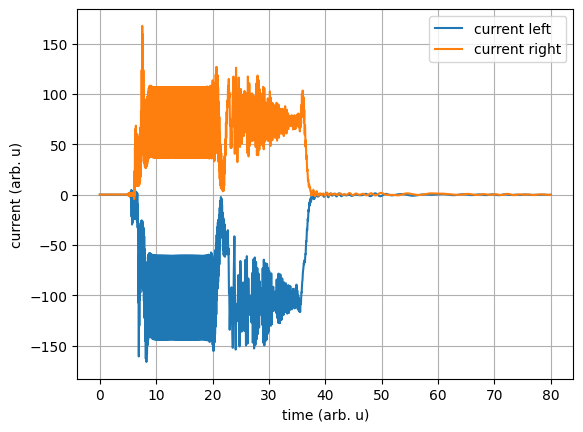

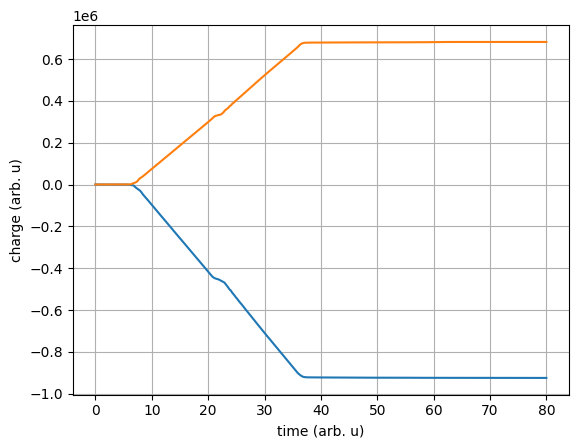

3. run:
-electron energy:7.5067258397628347.506725839762834
-electron wavenumber:11.638483267843084
Norm (t=0): 764.541, Norm (final): 780.924
Abs diff: 1.638e+01, Rel diff: 2.143e-02


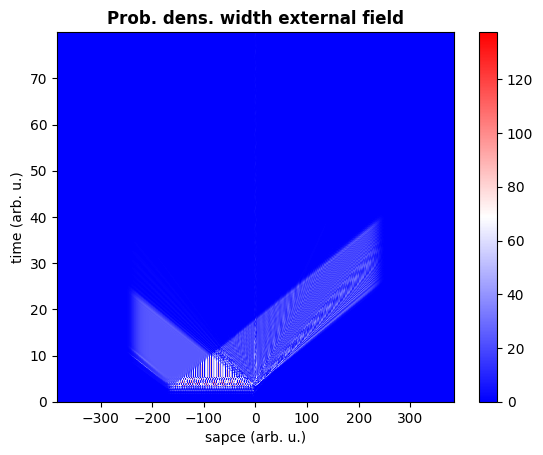

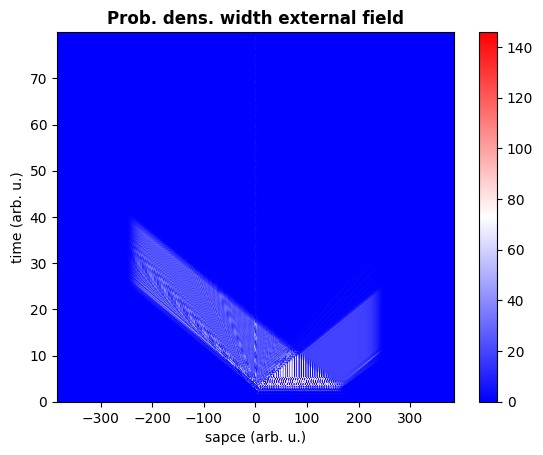

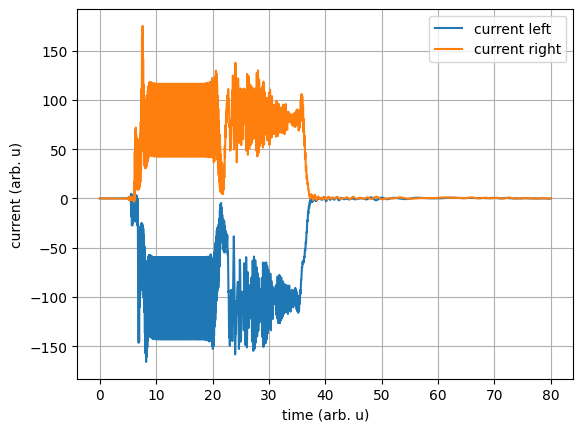

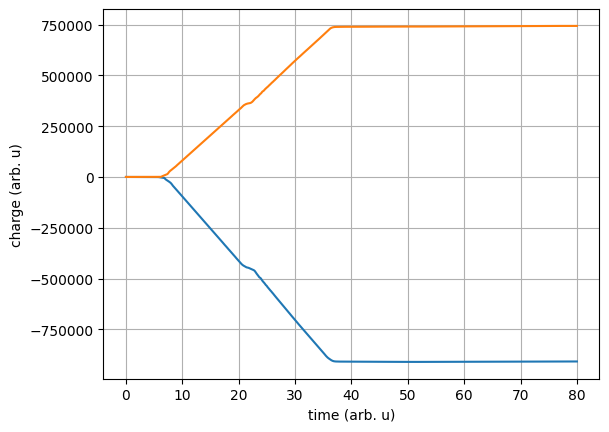

4. run:
-electron energy:7.5843962902691297.584396290269129
-electron wavenumber:11.700091028360644
Norm (t=0): 765.267, Norm (final): 781.277
Abs diff: 1.601e+01, Rel diff: 2.092e-02


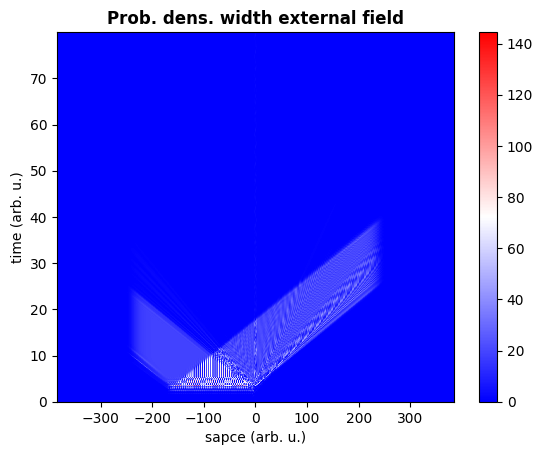

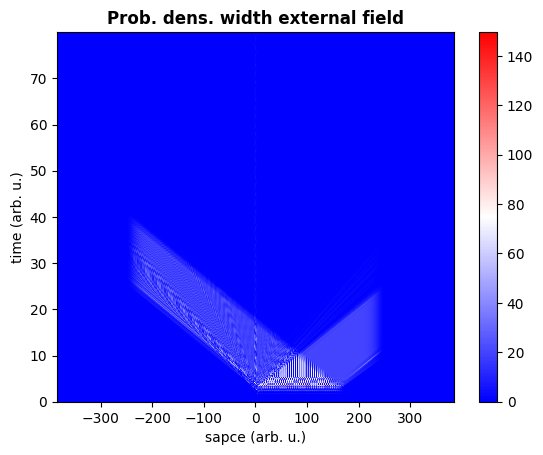

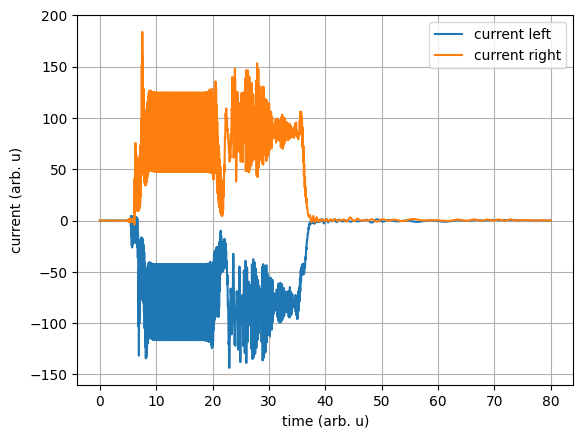

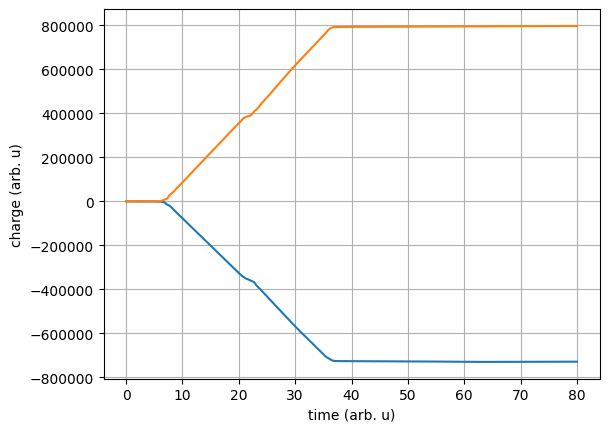

5. run:
-electron energy:7.6624346151285687.662434615128568
-electron wavenumber:11.761698788878206
Norm (t=0): 766.427, Norm (final): 786.732
Abs diff: 2.030e+01, Rel diff: 2.649e-02


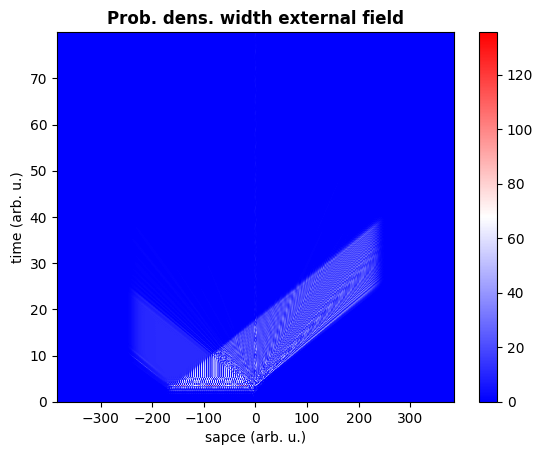

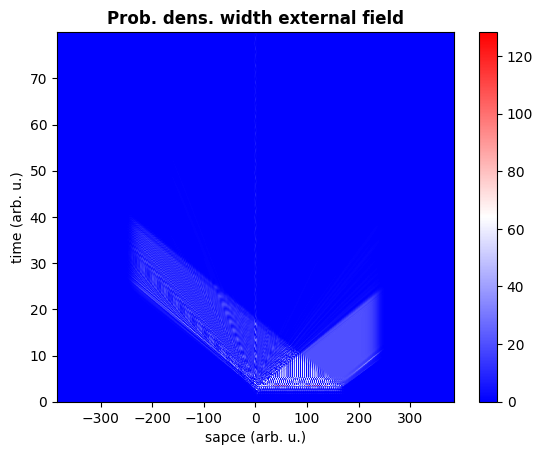

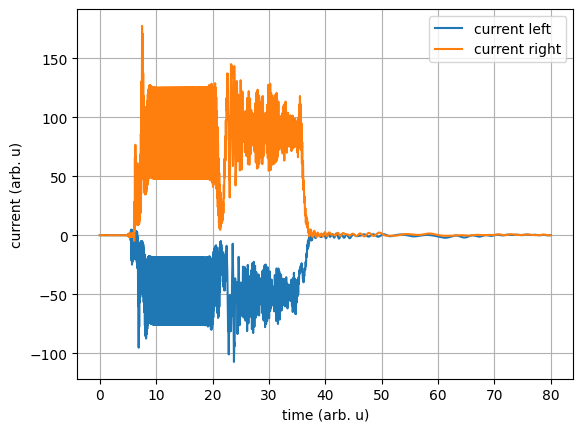

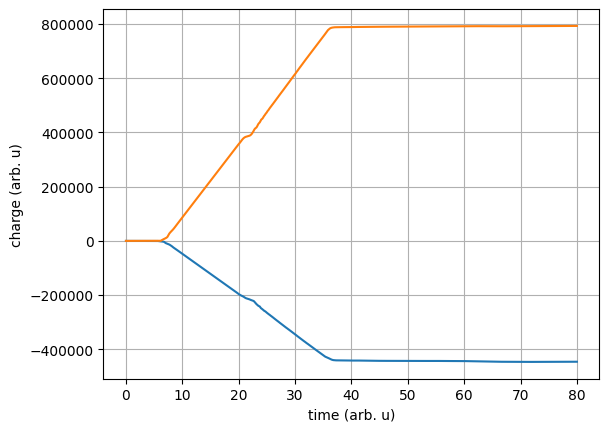

6. run:
-electron energy:7.7408401616480417.740840161648041
-electron wavenumber:11.823306549395767
Norm (t=0): 764.399, Norm (final): 781.738
Abs diff: 1.734e+01, Rel diff: 2.268e-02


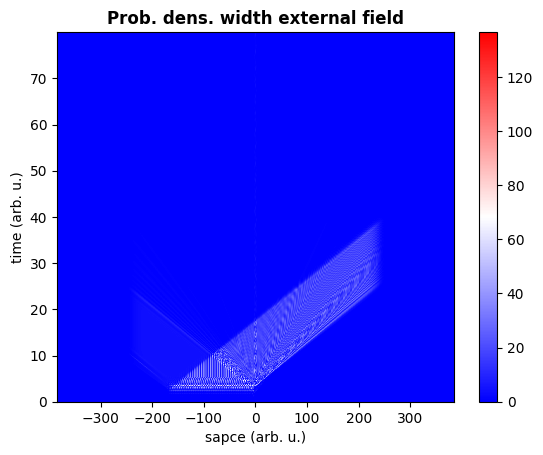

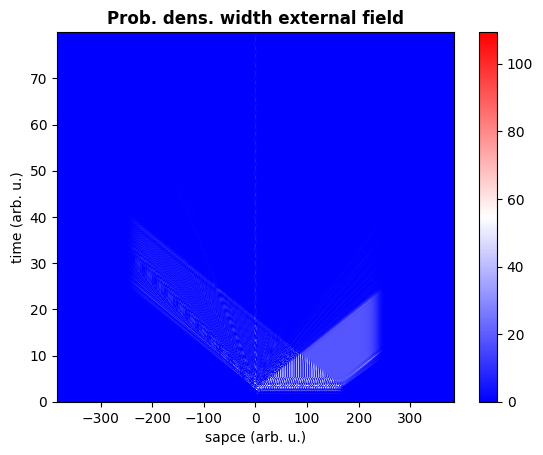

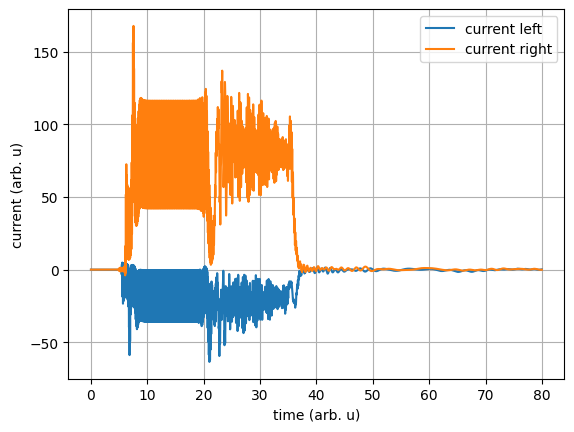

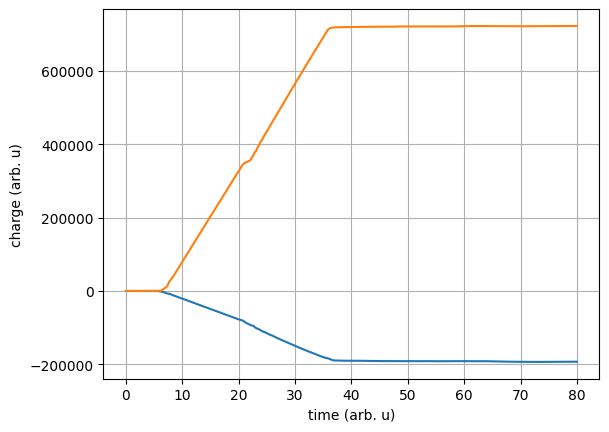

7. run:
-electron energy:7.8196122740631077.819612274063107
-electron wavenumber:11.884914309913327
Norm (t=0): 766.874, Norm (final): 784.771
Abs diff: 1.790e+01, Rel diff: 2.334e-02


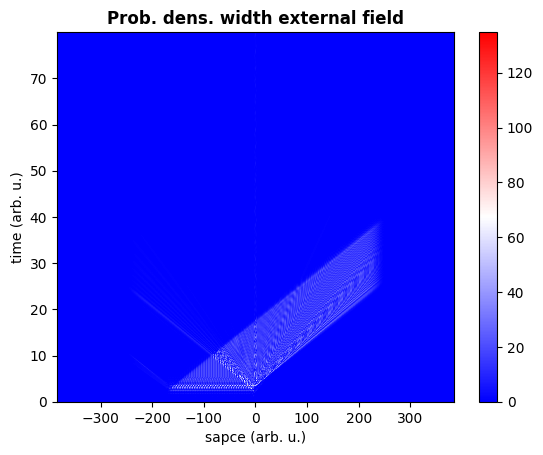

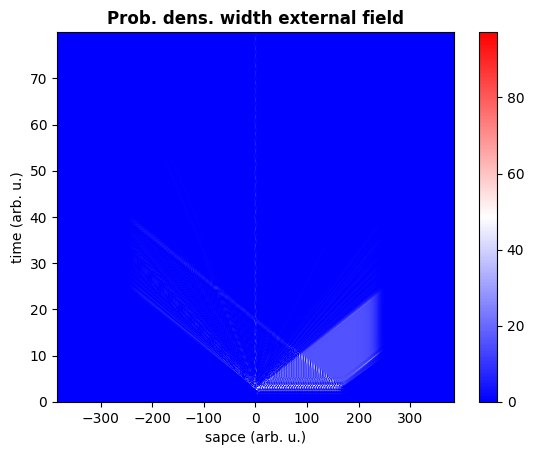

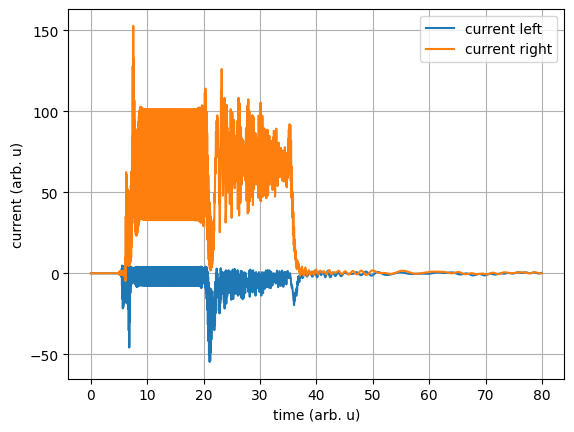

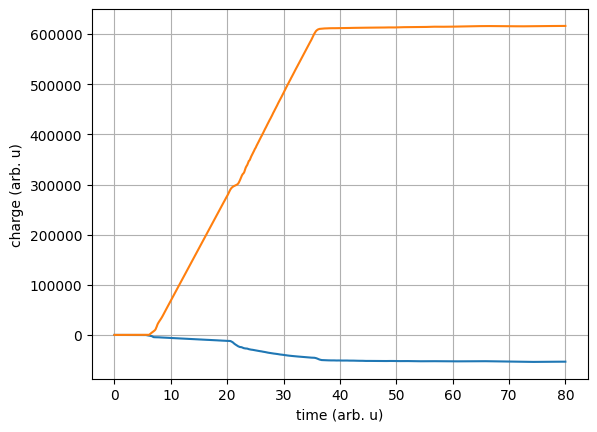

8. run:
-electron energy:7.8987502935434467.898750293543446
-electron wavenumber:11.946522070430888


In [ ]:
from scipy import integrate
import deepdish as dd
import gc
import os

def save_simulation_metadata(
    output_path,
    unit_sys,
    uxgrid,
    utgrid,
    v_cap,
    laserpot,
    modelpot,
    quasiparticles_pk,
    quasiparticles_mk,
    selected_indices
):
    import numpy as np
    if not hasattr(np, 'object'):
        np.object = object
    import deepdish as dd
    """Csak a szimuláció metaadatait menti ki, időfejlődés nélkül."""
    data = {}
    data['unit_sys'] = {
        'hb': unit_sys.hb,
        'm0': unit_sys.me,
        'k0': unit_sys.k0,
        'e0': unit_sys.e0
    }
    data['grid'] = {
        'uxgrid': np.array(uxgrid),
        'utgrid': np.array(utgrid)
    }
    if hasattr(modelpot, 'values'):
        pot_values = modelpot.values
    else:
        pot_values = modelpot(0)
    data['potential'] = {
        'values': np.array(pot_values),
        'grid': np.array(modelpot.grid)
    }
    data['vcap'] = [np.array(v) for v in v_cap] if v_cap is not None else None
    data['laser'] = {
        'spatial_min': getattr(laserpot, 'spatial_min', None),
        'spatial_max': getattr(laserpot, 'spatial_max', None),
        'temporal_min': getattr(laserpot, 'temporal_min', None),
        'temporal_max': getattr(laserpot, 'temporal_max', None),
        'noc': getattr(laserpot, 'noc', None),
        'amplitude': getattr(laserpot, 'amplitude', None),
        'beta': getattr(laserpot, 'beta', None)
    }
    qp_list = []
    for i, (qpk, qmk) in enumerate(zip(quasiparticles_pk, quasiparticles_mk)):
        qp_entry = {
            'energy': qpk.get('energy'),
            'wavenumber': qpk.get('wavenumber'),
            'transmission': qpk.get('transmission'),
            'reflection': qpk.get('reflection'),
            'state_pk': {
                'grid': np.array(qpk['state']['grid']),
                'value': np.array(qpk['state']['value'])
            },
            'state_mk': {
                'grid': np.array(qmk['state']['grid']),
                'value': np.array(qmk['state']['value'])
            }
        }
        qp_list.append(qp_entry)
    data['quasiparticles'] = qp_list
    data['selected_indices'] = list(selected_indices)
    dd.io.save(output_path, data)

def append_time_evolution_to_hdf5(output_path, qp_index, psi1_time_evolution_pk, psi_time_evolution_pk, psi1_time_evolution_mk, psi_time_evolution_mk):
    """Egy adott quasiparticle-hez fűzi hozzá az időfejlődés adatokat."""
    # deepdish nem támogatja a részleges írást, ezért beolvassuk, módosítjuk, visszaírjuk
    data = dd.io.load(output_path)
    if 'quasiparticles' not in data or qp_index >= len(data['quasiparticles']):
        raise IndexError("quasiparticle index out of range")
    data['quasiparticles'][qp_index]['time_evolution_pk'] = {
        'psi1_time_evolution': psi1_time_evolution_pk,
        'psi_time_evolution': psi_time_evolution_pk
    }
    data['quasiparticles'][qp_index]['time_evolution_mk'] = {
        'psi1_time_evolution': psi1_time_evolution_mk,
        'psi_time_evolution': psi_time_evolution_mk
    }
    dd.io.save(output_path, data)

# --- Output file path ---
output_path = os.path.join(directory_widget.value, output_filename_widget.value)

# --- For ciklus előtt: metaadatok mentése ---
save_simulation_metadata(
    output_path,
    unit_sys,
    uxgrid,
    utgrid,
    v_cap,
    laserpot,
    modelpot,
    quasiparticles_pk,
    quasiparticles_mk,
    states_compute_select.value
)

utgrid_dt = (utgrid[1] - utgrid[0])
t_start = utgrid[0]
t_stop = utgrid[-1]

for i, (qpk, qmk) in enumerate(zip(quasiparticles_to_compute_pk, quasiparticles_to_compute_mk), start=1):
    ein = qpk["energy"]
    kin = qpk["wavenumber"]
    print(str(i)+". run:")
    print("-electron energy:"+str(ein)+str(qpk["energy"]/unit_sys.hb))
    print("-electron wavenumber:"+str(kin))
    #print("-pulse width:"+str(laserpot.temporal_width))
    #print("-pulse omega0:"+str(laserpot.omega0))
    
    psipk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qpk["energy"]/unit_sys.hb,\
                                                psi0_initial = qpk["state"],\
                                                scalarpot = modelpot,\
                                                vectorpot=laserpot,\
                                                dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
                                                vcap=v_cap, mask=mask)

    psimk_te=quat.SplitTimeEvolutionCalculator(psi0_omega=qmk["energy"]/unit_sys.hb,\
                                                psi0_initial = qmk["state"],\
                                                scalarpot = modelpot,\
                                                vectorpot=laserpot,\
                                                dt=utgrid_dt, t_start=t_start, t_stop=t_stop,
                                                vcap=v_cap, mask=mask)
        
    psipk_te.run()
    psimk_te.run()

    # --- Csak az aktuális időfejlődést fűzzük hozzá a megfelelő indexhez ---
    qp_index = states_compute_select.value[i-1] if hasattr(states_compute_select, 'value') else i-1
    append_time_evolution_to_hdf5(
        output_path,
        qp_index,
        psipk_te.psi1_time_evolution,
        psipk_te.psi_time_evolution,
        psimk_te.psi1_time_evolution,
        psimk_te.psi_time_evolution
    )

    #plot final state
    # state_to_plot = psipk_te.psi_time_evolution["value"][:,-1]
    # plt.plot(uxgrid, np.real(state_to_plot),label="Re")
    # plt.plot(uxgrid, np.imag(state_to_plot),label="Im")
    # plt.plot(uxgrid, np.abs(state_to_plot),label="Abs")
    # plt.legend()
    # # plt.xlim(-10, 10)
    # plt.show()

    #plot final state
    # state_to_plot = psimk_te.psi_time_evolution["value"][:,-1]
    # plt.plot(uxgrid, np.real(state_to_plot),label="Re")
    # plt.plot(uxgrid, np.imag(state_to_plot),label="Im")
    # plt.plot(uxgrid, np.abs(state_to_plot),label="Abs")
    # plt.legend()
    # # plt.xlim(-10, 10)
    # plt.show()

    # Kezdőállapot (t=0) sűrűség
    psi0 = qpk["state"]["value"][mask]
    density0 = np.abs(psi0)**2
    norm0 = np.trapz(density0, uxgrid_masked)

    # Időfejlesztett állapot utolsó időpontban
    psi_final = psipk_te.psi_time_evolution["value"][:,-1]
    density_final = np.abs(psi_final)**2
    norm_final = np.trapz(density_final, uxgrid_masked)

    # Különbség és relatív eltérés
    abs_diff = np.abs(norm_final - norm0)
    rel_diff = abs_diff / norm0 if norm0 != 0 else np.nan

    print(f"Norm (t=0): {norm0:.6g}, Norm (final): {norm_final:.6g}")
    print(f"Abs diff: {abs_diff:.3e}, Rel diff: {rel_diff:.3e}")

    # --- Plotting the results ---
    #z_min, z_max = 0.0, 20.0
    Xp,Yp = np.meshgrid(uxgrid_masked,utgrid[:-1])
    Zp=np.transpose(quat.probability_density(psipk_te.psi1_time_evolution))       
    pcmp = plt.pcolormesh(Xp,Yp,Zp,cmap ='bwr') #, vmin = z_min, vmax = z_max) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
    plt.colorbar(pcmp)
    
    plt.title('Prob. dens. width external field', fontweight ="bold")
    plt.xlabel("sapce (arb. u.)")
    plt.ylabel("time (arb. u.)")
    #plt.xlim(uxgrid_masked[left_index-30], uxgrid_masked[left_index+30])
    plt.show()

    Xm,Ym = np.meshgrid(uxgrid_masked,utgrid[:-1])
    Zm=np.transpose(quat.probability_density(psimk_te.psi1_time_evolution))
    pcmm = plt.pcolormesh(Xm,Ym,Zm,cmap ='bwr')#, vmin = z_min, vmax = z_max) #plt.pcolormesh(X, Y, Z, cmap ='bwr', vmin = z_min, vmax = z_max)
    plt.colorbar(pcmm)
    
    plt.title('Prob. dens. width external field', fontweight ="bold")
    plt.xlabel("sapce (arb. u.)")
    plt.ylabel("time (arb. u.)")
    #plt.xlim(uxgrid_masked[left_index-30], uxgrid_masked[left_index+30])
    plt.show()

    # --- Charge current calculation and plotting ---

    # psi_left_pk = psipk_te.psi_time_evolution["value"][left_index,:]
    # dpsi_left_pk = (psipk_te.psi_time_evolution["value"][left_index+1,:]-psipk_te.psi_time_evolution["value"][left_index-1,:])/(2*uxgrid_dx)
    # j_left_pk = unit_sys.hb * np.imag(np.conj(psi_left_pk) * dpsi_left_pk) / unit_sys.me
    # psi_left_mk = psimk_te.psi_time_evolution["value"][left_index,:]
    # dpsi_left_mk = (psimk_te.psi_time_evolution["value"][left_index+1,:]-psimk_te.psi_time_evolution["value"][left_index-1,:])/(2*uxgrid_dx)
    # j_left_mk = unit_sys.hb * np.imag(np.conj(psi_left_mk) * dpsi_left_mk) / unit_sys.me
    # j_left = j_left_pk + j_left_mk

    # psi_right_pk = psipk_te.psi_time_evolution["value"][right_index,:]
    # dpsi_right_pk = (psipk_te.psi_time_evolution["value"][right_index+1,:]-psipk_te.psi_time_evolution["value"][right_index-1,:])/(2*uxgrid_dx)
    # j_right_pk = unit_sys.hb * np.imag(np.conj(psi_right_pk) * dpsi_right_pk) / unit_sys.me
    # psi_right_mk = psimk_te.psi_time_evolution["value"][right_index,:]
    # dpsi_right_mk = (psimk_te.psi_time_evolution["value"][right_index+1,:]-psimk_te.psi_time_evolution["value"][right_index-1,:])/(2*uxgrid_dx)
    # j_right_mk = unit_sys.hb * np.imag(np.conj(psi_right_mk) * dpsi_right_mk) / unit_sys.me
    # j_right = j_right_pk + j_right_mk

    # #plt.plot(utgrid[:-1],np.real(psi),label="Re psi")
    # #plt.plot(utgrid[:-1],np.real(dpsi),label="Re dpsi")
    # plt.plot(utgrid[:-1],j_left,label="current left")
    # #plt.plot(utgrid[:-1],j_left_pk,'-.',label="current left +k")
    # #plt.plot(utgrid[:-1],j_left_mk,'-.',label="current left -k")
    # plt.plot(utgrid[:-1],j_right,label="current right")
    # #plt.plot(utgrid[:-1],j_left_pk,'-.',label="current left +k")
    # #plt.plot(utgrid[:-1],j_left_mk,'-.',label="current left -k")
    # plt.legend()
    # plt.xlabel("time (arb. u)")
    # plt.ylabel("charge (arb. u.)")
    # plt.grid()
    # plt.show()
    current_prefactor = unit_sys.e0 * unit_sys.hb / unit_sys.me

    pc_pk = current_prefactor * quat.probability_current(psipk_te.psi_time_evolution)
    pc_mk = current_prefactor * quat.probability_current(psimk_te.psi_time_evolution)

    # pc_pk_left = quat.probability_current_at(psipk_te.psi_time_evolution, left_index)
    # pc_mk_left = quat.probability_current_at(psimk_te.psi_time_evolution, left_index)
    # pc_pk_right = quat.probability_current_at(psipk_te.psi_time_evolution, right_index)
    # pc_mk_right = quat.probability_current_at(psimk_te.psi_time_evolution, right_index)

    # plt.plot(utgrid[:-1], pc_pk[left_index,:],label="charge left +k")
    # plt.plot(utgrid[:-1], pc_pk[right_index,:],label="charge right +k")
    # plt.plot(utgrid[:-1], pc_mk[left_index,:],label="charge right -k")
    # plt.plot(utgrid[:-1], pc_mk[right_index,:],label="charge left -k")
    # plt.plot(utgrid[:-1],pc_pk_left,label="charge left +k")
    # plt.plot(utgrid[:-1],pc_mk_left,label="charge left -k")
    # plt.legend()
    # plt.xlabel("time (arb. u)")
    # plt.ylabel("charge (arb. u.)")
    # plt.grid()
    # plt.show()

    pc_sum=pc_pk+pc_mk

    pc_sum_left = pc_sum[left_index,:]
    pc_sum_right = pc_sum[right_index,:]
    # #pcsum_diff=pcsum_right-pcsum_left

    plt.plot(utgrid[:-1], pc_sum_left,label="current left")
    plt.plot(utgrid[:-1], pc_sum_right,label="current right")
    #plt.plot(utgrid[:-1], pc_pk[left_index,:]+pc_mk[left_index,:],label="charge left +k + -k")
    #plt.plot(utgrid[:-1], pc_pk[right_index,:]+pc_mk[right_index,:],label="charge right +k + -k")
    #plt.plot(utgrid[:-1],j_left,'-.',label="current left")
    #plt.plot(utgrid[:-1],j_right,'-.',label="current right")
    plt.xlabel("time (arb. u)")
    plt.ylabel("current (arb. u)")
    plt.legend()
    plt.grid()
    plt.show()

    charge_left = integrate.cumtrapz(pc_sum_left, initial=0)
    charge_right = integrate.cumtrapz(pc_sum_right, initial=0)
        # #charge_diff = integrate.cumtrapz(pcsum_diff, utgrid, initial=0)

    plt.plot(utgrid[:-1], charge_left,label="charge left")
    plt.plot(utgrid[:-1], charge_right,label="charge right")
    plt.xlabel("time (arb. u)")
    plt.ylabel("charge (arb. u)")
    plt.grid()
    plt.show()

    # Clear the plots to avoid memory issues
    plt.clf()
    plt.cla()
    plt.close('all')

    # Töröljük a változókat, hogy felszabadítsuk a memóriát
    del psipk_te
    del psimk_te
    del Xp, Yp, Zp, Xm, Ym, Zm
    del pc_pk, pc_mk, pc_sum
    del pc_sum_left, pc_sum_right
    del charge_left, charge_right
    del pcmp, pcmm
    gc.collect()